# Logistische Regression – Sentimentanalyse von Produktrezensionen

Trainiert eine logistische Regression auf TF-IDF-Features zur Klassifikation von Amazon-Rezensionen (1–5 Sterne).

**Split:** 70/15/15 (Train / Validation / Test)

**Daten:** `data/splits/train_0_50000_70_15_15.jsonl` etc.

## 1. Imports

In [1]:
import json
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report
)

# ============================================================
# KONFIGURATION: Project Root
# ============================================================
PROJECT_ROOT = Path("../")

DATA_DIR   = PROJECT_ROOT / "data" / "splits"
TRAIN_FILE = DATA_DIR / "train_0_50000_70_15_15.jsonl"
VAL_FILE   = DATA_DIR / "val_0_50000_70_15_15.jsonl"
TEST_FILE  = DATA_DIR / "test_0_50000_70_15_15.jsonl"

MODEL_DIR   = PROJECT_ROOT / "results" / "logistic" / "models"
METRICS_DIR = PROJECT_ROOT / "results" / "logistic" / "metrics"
FIGURES_DIR = PROJECT_ROOT / "results" / "logistic" / "figures"

for d in [MODEL_DIR, METRICS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars']

print(f"PROJECT_ROOT: {PROJECT_ROOT.resolve()}")
print(f"TRAIN_FILE existiert: {TRAIN_FILE.exists()}")
print(f"VAL_FILE   existiert: {VAL_FILE.exists()}")
print(f"TEST_FILE  existiert: {TEST_FILE.exists()}")
print("✓ Imports und Pfade initialisiert")

PROJECT_ROOT: C:\Develop\Python\nlp
TRAIN_FILE existiert: True
VAL_FILE   existiert: True
TEST_FILE  existiert: True
✓ Imports und Pfade initialisiert


## 2. Hyperparameter-Konfiguration

Alle tuningwürdigen Parameter zentral an einer Stelle.

| Parameter | Beschreibung | Typische Werte |
|---|---|---|
| `C` | Regularisierungsstärke (LogisticRegression) | 0.01 – 10.0 |
| `MAX_ITER` | Max. Iterationen bis zur Konvergenz | 100 – 1000 |
| `SOLVER` | Optimierungsalgorithmus | 'lbfgs', 'saga', 'liblinear' |
| `MAX_FEATURES` | Max. Anzahl TF-IDF-Features | 1.000 – 100.000 |
| `MIN_DF` | Min. Dokumenthäufigkeit eines Terms | 1 – 10 |
| `MAX_DF` | Max. Dokumenthäufigkeit eines Terms | 0.7 – 1.0 |
| `NGRAM_RANGE` | Uni- und/oder Bigramme | (1,1), (1,2) |
| `STOP_WORDS` | Stoppwörter entfernen | 'english', None |
| `SUBLINEAR_TF` | Logarithmische TF-Skalierung | True, False |

In [2]:
# ============================================================
# HYPERPARAMETER – hier anpassen!
# ============================================================

# LogisticRegression
C        = 1.0        # Regularisierungsstärke; kleiner = stärkere Regularisierung
MAX_ITER = 1000       # Max. Iterationen bis zur Konvergenz
SOLVER   = 'saga'     # Optimierungsalgorithmus; 'saga' empfohlen für große Datensätze

# TF-IDF Vektorizer
MAX_FEATURES = 10000    # Anzahl der Features (Vokabular-Größe)
MIN_DF       = 2        # Term muss in mind. N Dokumenten vorkommen
MAX_DF       = 0.95     # Term darf in höchstens X% der Dokumente vorkommen
NGRAM_RANGE  = (1, 2)   # (1,1) = Unigramme; (1,2) = Uni- + Bigramme
STOP_WORDS   = 'english'  # Stoppwörter: 'english' oder None
SUBLINEAR_TF = False    # True = log(TF) statt TF; oft besser bei langen Texten

print("Aktuelle Hyperparameter:")
print(f"  C            = {C}")
print(f"  MAX_ITER     = {MAX_ITER}")
print(f"  SOLVER       = {SOLVER}")
print(f"  MAX_FEATURES = {MAX_FEATURES}")
print(f"  MIN_DF       = {MIN_DF}")
print(f"  MAX_DF       = {MAX_DF}")
print(f"  NGRAM_RANGE  = {NGRAM_RANGE}")
print(f"  STOP_WORDS   = {STOP_WORDS}")
print(f"  SUBLINEAR_TF = {SUBLINEAR_TF}")

Aktuelle Hyperparameter:
  C            = 1.0
  MAX_ITER     = 1000
  SOLVER       = saga
  MAX_FEATURES = 10000
  MIN_DF       = 2
  MAX_DF       = 0.95
  NGRAM_RANGE  = (1, 2)
  STOP_WORDS   = english
  SUBLINEAR_TF = False


## 3. Daten laden

In [3]:
def load_data(filepath):
    """Lädt JSONL-Datei und kombiniert title + text."""
    texts, ratings = [], []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            data = json.loads(line)
            texts.append(f"{data['title']} {data['text']}")
            ratings.append(int(data['rating']))
    return texts, ratings

print("Lade Trainingsdaten ...")
X_train_texts, y_train = load_data(TRAIN_FILE)
print(f"  Train:      {len(X_train_texts):>7,} Samples")

print("Lade Validierungsdaten ...")
X_val_texts, y_val = load_data(VAL_FILE)
print(f"  Validation: {len(X_val_texts):>7,} Samples")

print("Lade Testdaten ...")
X_test_texts, y_test = load_data(TEST_FILE)
print(f"  Test:       {len(X_test_texts):>7,} Samples")

Lade Trainingsdaten ...
  Train:      140,000 Samples
Lade Validierungsdaten ...
  Validation:  30,000 Samples
Lade Testdaten ...
  Test:        30,000 Samples


## 4. TF-IDF Vektorisierung

In [4]:
print("Vektorisierung (TF-IDF) ...")
vectorizer = TfidfVectorizer(
    max_features=MAX_FEATURES,
    min_df=MIN_DF,
    max_df=MAX_DF,
    lowercase=True,
    stop_words=STOP_WORDS,
    ngram_range=NGRAM_RANGE,
    sublinear_tf=SUBLINEAR_TF
)

X_train = vectorizer.fit_transform(X_train_texts)
X_val   = vectorizer.transform(X_val_texts)
X_test  = vectorizer.transform(X_test_texts)

print(f"✓ Feature-Dimension: {X_train.shape[1]:,}")
print(f"✓ Train-Matrix:      {X_train.shape}")
print(f"✓ Val-Matrix:        {X_val.shape}")
print(f"✓ Test-Matrix:       {X_test.shape}")

Vektorisierung (TF-IDF) ...
✓ Feature-Dimension: 10,000
✓ Train-Matrix:      (140000, 10000)
✓ Val-Matrix:        (30000, 10000)
✓ Test-Matrix:       (30000, 10000)


## 5. Modell trainieren

In [5]:
print("Trainiere Logistische Regression ...")
model = LogisticRegression(
    C=C,
    max_iter=MAX_ITER,
    solver=SOLVER,
    random_state=42
)
model.fit(X_train, y_train)
print("✓ Training abgeschlossen")

Trainiere Logistische Regression ...
✓ Training abgeschlossen


## 6. Validierung (Hyperparameter-Check)

In [6]:
y_val_pred = model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_accuracy:.4f}")
print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred, target_names=CLASS_NAMES))

Validation Accuracy: 0.7178

Classification Report (Validation):
              precision    recall  f1-score   support

      1 Star       0.65      0.61      0.63      1844
     2 Stars       0.36      0.11      0.17      1280
     3 Stars       0.43      0.26      0.33      2450
     4 Stars       0.41      0.20      0.27      4761
     5 Stars       0.78      0.95      0.85     19665

    accuracy                           0.72     30000
   macro avg       0.53      0.43      0.45     30000
weighted avg       0.66      0.72      0.67     30000



## 7. Evaluierung auf Testdaten

In [7]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"{'='*60}")
print(f"TEST-EVALUIERUNG")
print(f"{'='*60}")
print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

TEST-EVALUIERUNG
Accuracy: 0.7299

Confusion Matrix:
[[ 1219   109   160    54   419]
 [  291   147   260   109   403]
 [  148   111   643   390   999]
 [   50    29   265   884  3443]
 [   73    19   171   600 19004]]

Classification Report:
              precision    recall  f1-score   support

      1 Star       0.68      0.62      0.65      1961
     2 Stars       0.35      0.12      0.18      1210
     3 Stars       0.43      0.28      0.34      2291
     4 Stars       0.43      0.19      0.26      4671
     5 Stars       0.78      0.96      0.86     19867

    accuracy                           0.73     30000
   macro avg       0.54      0.43      0.46     30000
weighted avg       0.68      0.73      0.69     30000



## 8. Confusion Matrix visualisieren

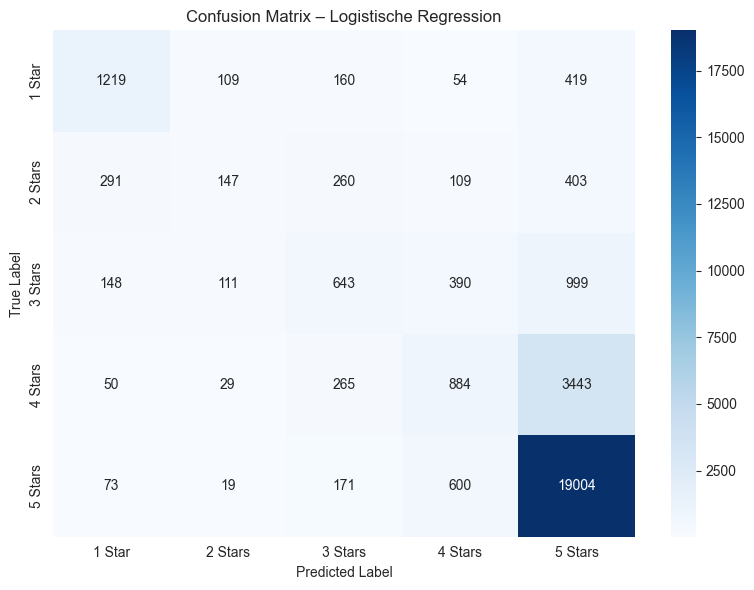

✓ Gespeichert: ..\results\logistic\figures\confusion_matrix_logistic.png


In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=ax
)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix – Logistische Regression')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confusion_matrix_logistic.png', dpi=150)
plt.show()
print(f"✓ Gespeichert: {FIGURES_DIR / 'confusion_matrix_logistic.png'}")

### Confusion Matrix – Interpretation

**Struktur:**
- Zeilen = True Label (tatsächliche Klasse)
- Spalten = Predicted Label (vom Modell vorhergesagte Klasse)

**Für jede Klasse (Beispiel: "5 Stars"):**

**TP (True Positives) – Diagonale:** Korrekt als diese Klasse vorhergesagt.

**FP (False Positives) – Spalte (ohne Diagonale):** Fälschlicherweise als diese Klasse klassifiziert.

**FN (False Negatives) – Zeile (ohne Diagonale):** Gehört zu dieser Klasse, wurde aber falsch klassifiziert.

**TN (True Negatives):** Alles außerhalb der Zeile und Spalte dieser Klasse.

## 9. Ergebnisse speichern

In [9]:
# Metriken als JSON
results = {
    'accuracy': float(accuracy),
    'val_accuracy': float(val_accuracy),
    'confusion_matrix': conf_matrix.tolist(),
    'num_train_samples': len(y_train),
    'num_val_samples': len(y_val),
    'num_test_samples': len(y_test),
    'classes': CLASS_NAMES,
    'hyperparameters': {
        'C': C,
        'max_iter': MAX_ITER,
        'solver': SOLVER,
        'max_features': MAX_FEATURES,
        'min_df': MIN_DF,
        'max_df': MAX_DF,
        'ngram_range': list(NGRAM_RANGE),
        'stop_words': STOP_WORDS,
        'sublinear_tf': SUBLINEAR_TF
    }
}
with open(METRICS_DIR / 'logistic_metrics.json', 'w') as f:
    json.dump(results, f, indent=2)

# CSV für Vergleiche
hyperparams_str = (
    f"C: {C} | max_iter: {MAX_ITER} | solver: {SOLVER} | max_features: {MAX_FEATURES} | "
    f"min_df: {MIN_DF} | max_df: {MAX_DF} | ngram_range: {NGRAM_RANGE} | "
    f"stop_words: {STOP_WORDS} | sublinear_tf: {SUBLINEAR_TF}"
)
pd.DataFrame({
    'Model':           ['Logistic Regression'],
    'Accuracy':        [accuracy],
    'Val_Accuracy':    [val_accuracy],
    'Train_Samples':   [len(y_train)],
    'Test_Samples':    [len(y_test)],
    'Hyperparameters': [hyperparams_str]
}).to_csv(METRICS_DIR / 'logistic_results.csv', index=False, sep=';')

with open(MODEL_DIR / 'logistic_model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open(MODEL_DIR / 'logistic_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print(f"✓ Metriken gespeichert in {METRICS_DIR}")
print(f"✓ Modell gespeichert in {MODEL_DIR}")

✓ Metriken gespeichert in ..\results\logistic\metrics
✓ Modell gespeichert in ..\results\logistic\models
